## 2. Add Stats to Shapefile (Arctic Rivers)

Merges `arctic_stats.csv` into the segments shapefile and writes
`export/arctic_rivers_segments_stats.shp`.

**Input:** `arctic_stats.csv` (from `fetch_stats_from_rasdaman_coverage.ipynb`) +
`segments/arctic_rivers_segments_3338.shp`  
**Output:** `export/arctic_rivers_segments_stats.shp`

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import itertools
from pathlib import Path

In [2]:
SEGMENTS_PATH = "segments/arctic_rivers_segments_3338.shp"
STATS_CSV     = "arctic_stats.csv"
OUTPUT_PATH   = "export/arctic_rivers_segments_stats.shp"

Path("export").mkdir(exist_ok=True)

In [3]:
gdf   = gpd.read_file(SEGMENTS_PATH)
stats = pd.read_csv(STATS_CSV, index_col="stream_id")

print(f"Segments: {len(gdf)} rows")
print(f"Stats:    {len(stats)} rows, {len(stats.columns)} columns")

Segments: 34208 rows
Stats:    34346 rows, 66 columns


In [4]:
merged = gdf.merge(stats, left_on="COMID", right_index=True, how="left")

# Drop segments with no stats at all
stat_cols = stats.columns.tolist()
no_stats  = merged[stat_cols].isna().all(axis=1)
print(f"Dropping {no_stats.sum()} segments with no stats")
merged = merged[~no_stats].reset_index(drop=True)

print(f"Output: {len(merged)} segments")
merged.head(2)

Dropping 0 segments with no stats
Output: 34208 segments


,COMID,geometry,ma12_min_d,ma12_avg_d,ma12_max_d,ma13_min_d,ma13_avg_d,ma13_max_d,ma14_min_d,ma14_avg_d,...,tl1_avg_d,tl1_max_d,ma99_min_d,ma99_avg_d,ma99_max_d,ma99_hist,dh15_hist,dl16_hist,fh1_hist,fl1_hist
0,81000004,"LINESTRING (-55856.646 2319023.490, -55825.464...",-44.30,25.49,248.38,-41.19,-6.44,76.50,-36.32,-15.55,...,-5.61,-3.04,3.67,9.95,19.05,4160.15,22.75,74.0,3.68,0.97
1,81000005,"LINESTRING (-72325.339 2318174.181, -72353.885...",-31.24,40.59,216.36,-63.35,-20.53,33.89,-39.89,-7.65,...,-6.47,-2.41,1.60,8.32,16.69,3404.80,32.67,87.0,3.19,0.87


### Visualize

Pick a few variables and plot them.

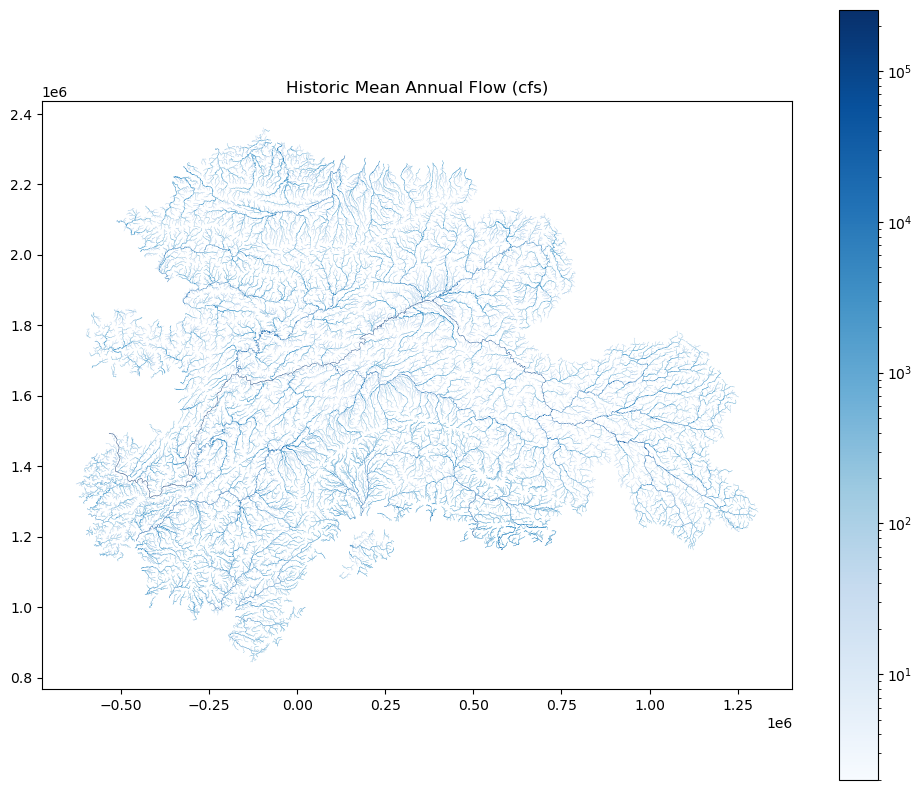

In [5]:
# Historic mean annual flow — default statistic shown in the web app map
# Logarithmic color scale to better show variation
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
merged.plot(column="ma99_hist", ax=ax, cmap="Blues", norm=colors.LogNorm(), legend=True, linewidth=0.3)
plt.title("Historic Mean Annual Flow (cfs)")
plt.tight_layout()

In [6]:
VARS_META = {
    "ma12": {"var_description": "Mean January flow",         "stats": ["ma12_min_d", "ma12_avg_d", "ma12_max_d"], "units": "cfs",            "difference": "percentage"},
    "ma13": {"var_description": "Mean February flow",        "stats": ["ma13_min_d", "ma13_avg_d", "ma13_max_d"], "units": "cfs",            "difference": "percentage"},
    "ma14": {"var_description": "Mean March flow",           "stats": ["ma14_min_d", "ma14_avg_d", "ma14_max_d"], "units": "cfs",            "difference": "percentage"},
    "ma15": {"var_description": "Mean April flow",           "stats": ["ma15_min_d", "ma15_avg_d", "ma15_max_d"], "units": "cfs",            "difference": "percentage"},
    "ma16": {"var_description": "Mean May flow",             "stats": ["ma16_min_d", "ma16_avg_d", "ma16_max_d"], "units": "cfs",            "difference": "percentage"},
    "ma17": {"var_description": "Mean June flow",            "stats": ["ma17_min_d", "ma17_avg_d", "ma17_max_d"], "units": "cfs",            "difference": "percentage"},
    "ma18": {"var_description": "Mean July flow",            "stats": ["ma18_min_d", "ma18_avg_d", "ma18_max_d"], "units": "cfs",            "difference": "percentage"},
    "ma19": {"var_description": "Mean August flow",          "stats": ["ma19_min_d", "ma19_avg_d", "ma19_max_d"], "units": "cfs",            "difference": "percentage"},
    "ma20": {"var_description": "Mean September flow",       "stats": ["ma20_min_d", "ma20_avg_d", "ma20_max_d"], "units": "cfs",            "difference": "percentage"},
    "ma21": {"var_description": "Mean October flow",         "stats": ["ma21_min_d", "ma21_avg_d", "ma21_max_d"], "units": "cfs",            "difference": "percentage"},
    "ma22": {"var_description": "Mean November flow",        "stats": ["ma22_min_d", "ma22_avg_d", "ma22_max_d"], "units": "cfs",            "difference": "percentage"},
    "ma23": {"var_description": "Mean December flow",        "stats": ["ma23_min_d", "ma23_avg_d", "ma23_max_d"], "units": "cfs",            "difference": "percentage"},
    "dh1":  {"var_description": "Annual Maximum Daily Flow", "stats": ["dh1_min_d",  "dh1_max_d"],               "units": "cfs",            "difference": "percentage"},
    "dl1":  {"var_description": "Annual Minimum Daily Flow", "stats": ["dl1_min_d",  "dl1_max_d"],               "units": "cfs",            "difference": "percentage"},
    "dh15": {"var_description": "High Flow Pulse Duration",  "stats": ["dh15_min_d", "dh15_avg_d", "dh15_max_d"], "units": "days per year",  "difference": "absolute"},
    "dl16": {"var_description": "Low Flow Pulse Duration",   "stats": ["dl16_min_d", "dl16_avg_d", "dl16_max_d"], "units": "days per year",  "difference": "absolute"},
    "fh1":  {"var_description": "High Flood Pulse Count",    "stats": ["fh1_min_d",  "fh1_avg_d",  "fh1_max_d"],  "units": "events per year","difference": "absolute"},
    "fl1":  {"var_description": "Low Flood Pulse Count",     "stats": ["fl1_min_d",  "fl1_avg_d",  "fl1_max_d"],  "units": "events per year","difference": "absolute"},
    "th1":  {"var_description": "Julian Date of Annual Maximum", "stats": ["th1_min_d", "th1_avg_d", "th1_max_d"], "units": "day of year",  "difference": "absolute"},
    "tl1":  {"var_description": "Julian Date of Annual Minimum", "stats": ["tl1_min_d", "tl1_avg_d", "tl1_max_d"], "units": "day of year",  "difference": "absolute"},
    "ma99": {"var_description": "Mean annual flow",          "stats": ["ma99_min_d", "ma99_avg_d", "ma99_max_d"], "units": "cfs",            "difference": "percentage"},
}

In [7]:
def diff_plot(stat, desc, units, method):
    if "avg" not in stat:
        print("skipping", stat)
        return

    print("plotting", stat, desc, units, method)

    if method == "percentage":
        divnorm = colors.TwoSlopeNorm(vmin=-100, vcenter=0, vmax=100)
    else:
        vmin = merged[stat].min()
        vmax = merged[stat].max()
        if abs(vmin) > abs(vmax):
            divnorm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=-vmin)
        else:
            divnorm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    merged.plot(ax=ax, color="lightgray", linewidth=0.3, zorder=0)
    merged.plot(column=stat, ax=ax, cmap="BrBG", norm=divnorm, legend=True, linewidth=0.3, zorder=1)
    plt.title(f"Change in {desc} ({units}): {method}")
    plt.show()

skipping ma12_min_d
plotting ma12_avg_d Mean January flow cfs percentage


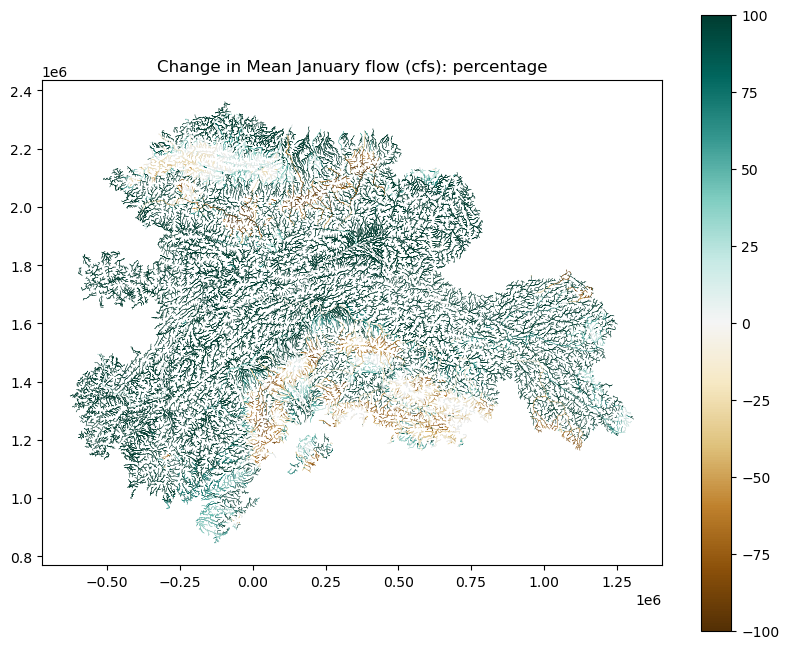

skipping ma12_max_d
skipping ma13_min_d
plotting ma13_avg_d Mean February flow cfs percentage


In [ ]:
for var, v in VARS_META.items():
    for stat, desc, units, method in zip(
        v["stats"],
        itertools.cycle([v["var_description"]]),
        itertools.cycle([v["units"]]),
        itertools.cycle([v["difference"]]),
    ):
        diff_plot(stat, desc, units, method)

### Drop

Drop the `th1` and `tl1` columns before saving — timing stats are computed but not used in the app.

In [ ]:
cols_to_drop = [c for c in merged.columns if "th1" in c or "tl1" in c]
print("Dropping:", cols_to_drop)
gdf_stats_to_save = merged.drop(columns=cols_to_drop)

### Save

In [ ]:
gdf_stats_to_save.to_file(OUTPUT_PATH)
print(f"Wrote {OUTPUT_PATH}")